# Ejercicio Laboratorio 3
Importar una base de datos de physionet y mostrar por lo menos 3 gráficas de esta

In [22]:
import wfdb
from scipy import signal

In [13]:
#Señal 1
record1 = wfdb.rdrecord('16265', pn_dir='nsrdb', sampfrom=0, sampto=3600)        #10 segundos
# Leer anotaciones (si existen para ese registro)
annotation1 = wfdb.rdann('16265', 'atr',  pn_dir='nsrdb', sampfrom=0, sampto=3600)
# Tipo: numpy array
# Forma: (N, canales)
signal1 = record1.p_signal
fs1 = record1.fs

In [14]:
#Señal 2
record2 = wfdb.rdrecord('16272', pn_dir='nsrdb', sampfrom=0, sampto=3600)        #10 segundos
# Leer anotaciones (si existen para ese registro)
annotation2 = wfdb.rdann('16272', 'atr',  pn_dir='nsrdb', sampfrom=0, sampto=3600)
# Tipo: numpy array
# Forma: (N, canales)
signal2 = record2.p_signal
fs2 = record2.fs

In [15]:
#Señal 1
record3 = wfdb.rdrecord('16420', pn_dir='nsrdb', sampfrom=0, sampto=3600)        #10 segundos
# Leer anotaciones (si existen para ese registro)
annotation3 = wfdb.rdann('16420', 'atr',  pn_dir='nsrdb', sampfrom=0, sampto=3600)
# Tipo: numpy array
# Forma: (N, canales)
signal3 = record3.p_signal
fs3 = record3.fs

## Gráficas Amplitud vs Tiempo

In [16]:
import matplotlib.pyplot as plt
import numpy as np

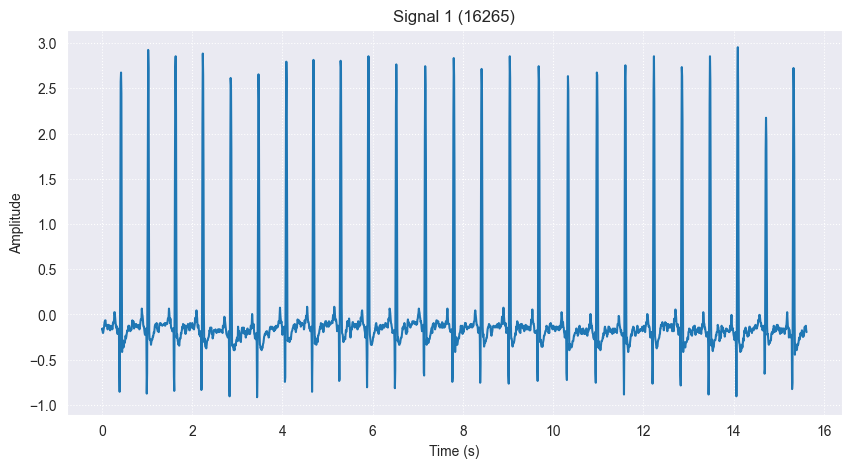

In [17]:
N1 = signal1.shape[0]
n1 = np.arange(N1)
t1 = n1/fs1

plt.figure(figsize=(10,5))
plt.plot(t1[:2000], signal1[:2000,0])
plt.title("Signal 1 (16265)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(ls=":")
plt.show()

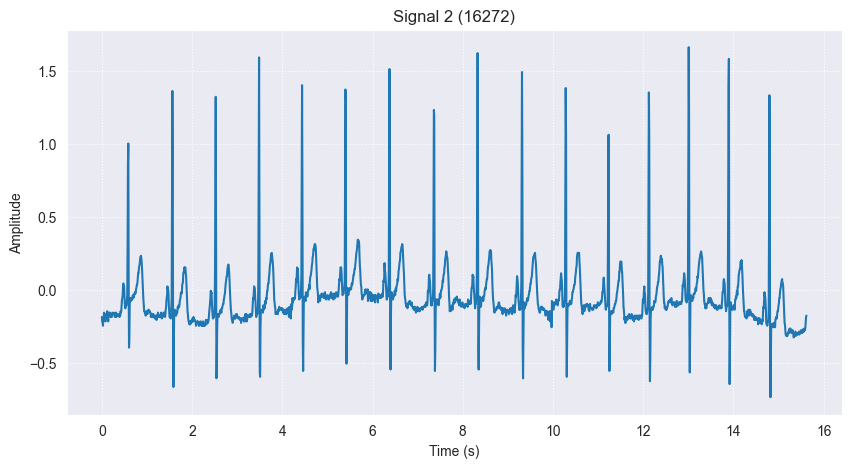

In [18]:
N2 = signal2.shape[0]
n2 = np.arange(N2)
t2 = n2/fs2

plt.figure(figsize=(10,5))
plt.plot(t2[:2000], signal2[:2000,0])
plt.title("Signal 2 (16272)")
plt.xlabel("Time (s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(ls=":")
plt.show()

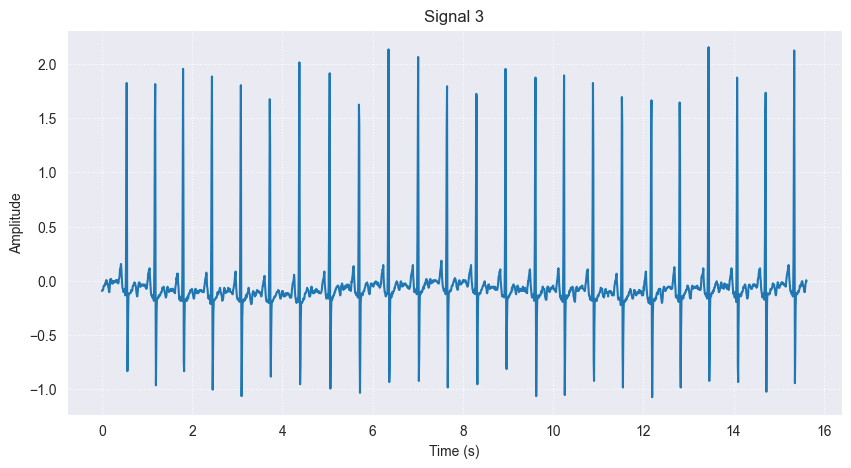

In [25]:
N3 = signal3.shape[0]
n3 = np.arange(N3)
t3 = n3/fs3

plt.figure(figsize=(10,5))
plt.plot(t3[:2000], signal3[:2000,0])
plt.title("Signal 3")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(ls=":")
plt.show()

## FFT

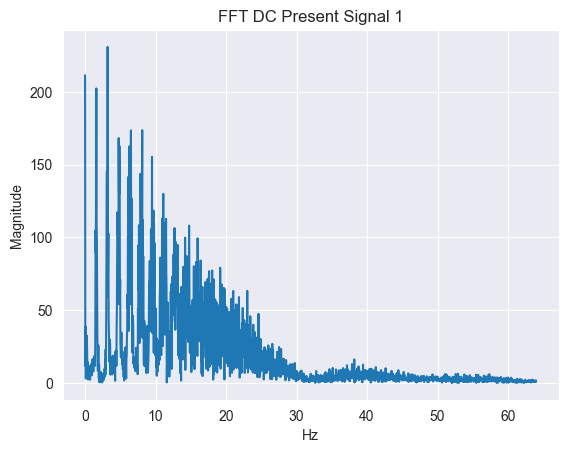

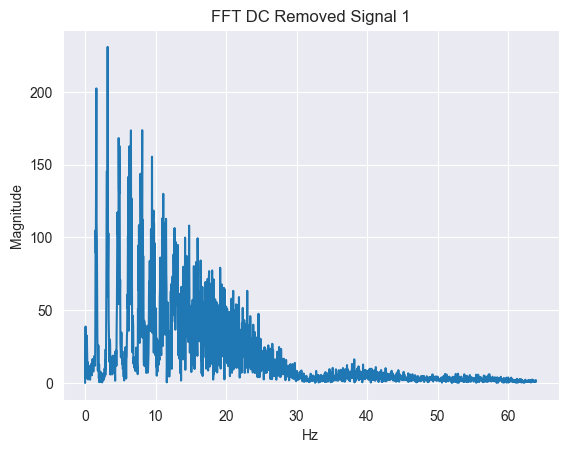

In [26]:
x1 = signal1[:,0]
x_dc_removed1 = x1 - np.mean(x1)
#Señal pura
X1 = np.fft.fft(x1)
freqs1 = np.fft.fftfreq(len(x1), 1/fs1)

plt.plot(freqs1[:len(x1)//2], np.abs(X1[:len(x1)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.title('FFT DC Present Signal 1')
plt.show()

#Componente DC removido
X1 = np.fft.fft(x_dc_removed1)
freqs1 = np.fft.fftfreq(len(x_dc_removed1), 1/fs1)

plt.plot(freqs1[:len(x_dc_removed1)//2], np.abs(X1[:len(x_dc_removed1)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.title('FFT DC Removed Signal 1')
plt.show()

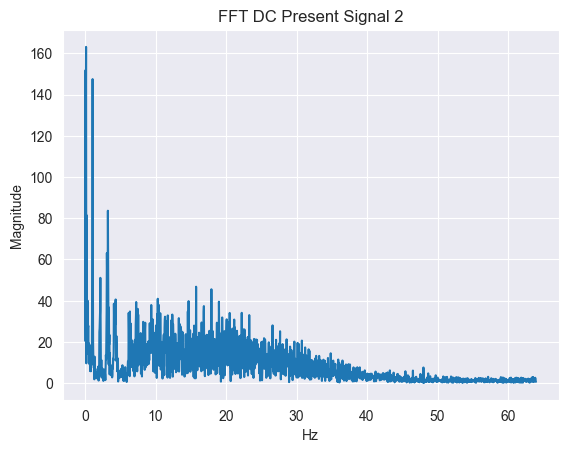

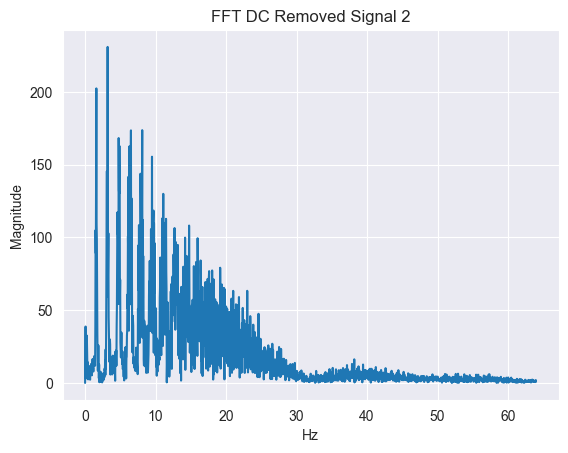

In [27]:
x2 = signal2[:,0]
x_dc_removed2 = x2 - np.mean(x2)
#Señal pura
X2 = np.fft.fft(x2)
freqs2 = np.fft.fftfreq(len(x2), 1/fs2)

plt.plot(freqs2[:len(x1)//2], np.abs(X2[:len(x2)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.title('FFT DC Present Signal 2')
plt.show()

#Componente DC removido
X2 = np.fft.fft(x_dc_removed1)
freqs2 = np.fft.fftfreq(len(x_dc_removed2), 1/fs2)

plt.plot(freqs2[:len(x_dc_removed2)//2], np.abs(X2[:len(x_dc_removed2)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.title('FFT DC Removed Signal 2')
plt.show()

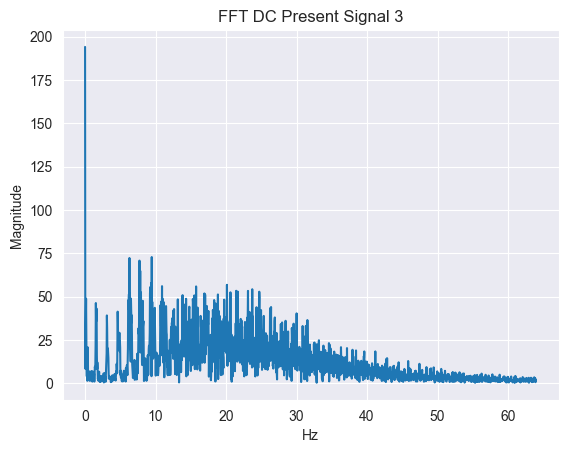

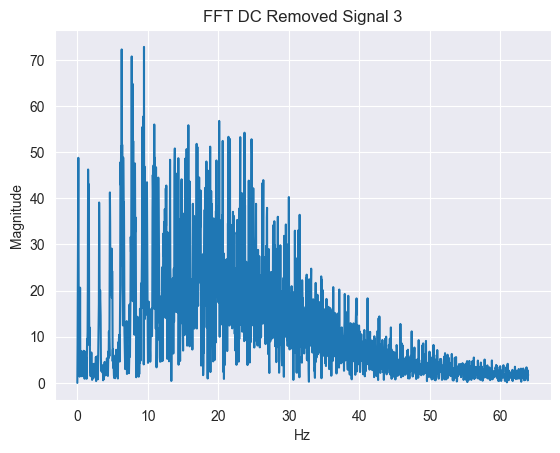

In [28]:
x3= signal3[:,0]
x_dc_removed3 = x3 - np.mean(x3)
#Señal pura
X3 = np.fft.fft(x3)
freqs3 = np.fft.fftfreq(len(x3), 1/fs3)

plt.plot(freqs3[:len(x3)//2], np.abs(X3[:len(x3)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.title('FFT DC Present Signal 3')
plt.show()

#Componente DC removido
X3 = np.fft.fft(x_dc_removed3)
freqs3 = np.fft.fftfreq(len(x_dc_removed3), 1/fs3)

plt.plot(freqs3[:len(x_dc_removed3)//2], np.abs(X3[:len(x_dc_removed3)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.title('FFT DC Removed Signal 3')
plt.show()

## SFTF

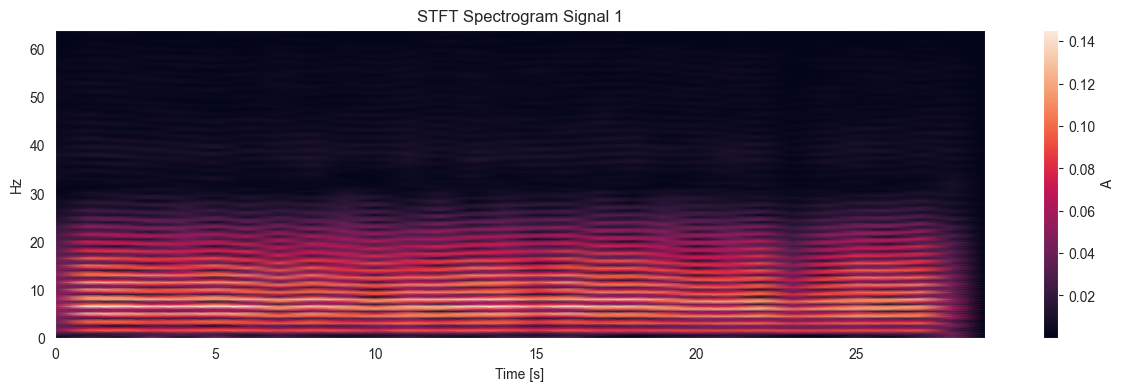

In [38]:
f, t, Zxx = signal.stft(x_dc_removed1, fs1, nperseg=256)

# Graficar el espectrograma
plt.figure(figsize=(15, 4))
plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.title('STFT Spectrogram Signal 1')
plt.ylabel('Hz')
plt.xlabel('Time [s]')
plt.colorbar(label='A')
plt.show()

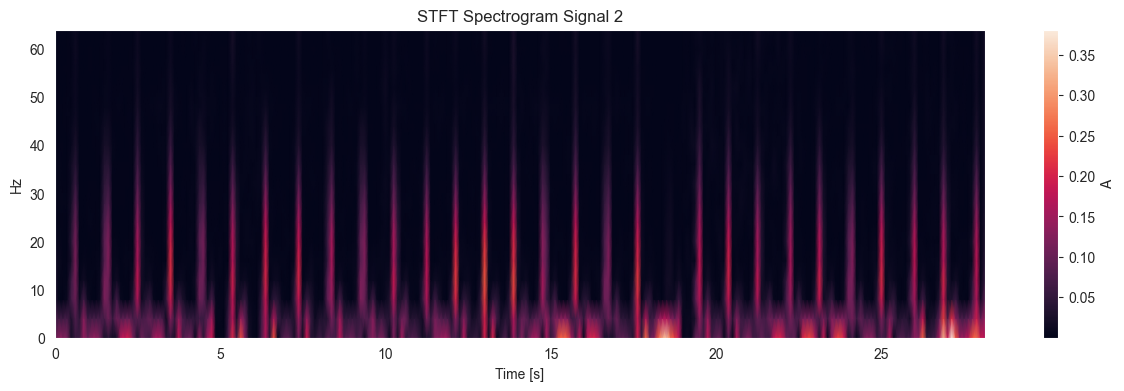

In [41]:
f, t, Zxx = signal.stft(x_dc_removed2, fs2, nperseg=32)
#Esta señal tiene un compartamiento especial, en ventanas más grandes se pierde la información de estos picos verticales
#Por este motivo estoy usando un  tamaño de ventan menor en comparación a las otras dos señales
# Graficar el espectrograma
plt.figure(figsize=(15, 4))
plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.title('STFT Spectrogram Signal 2')
plt.ylabel('Hz')
plt.xlabel('Time [s]')
plt.colorbar(label='A')
plt.show()

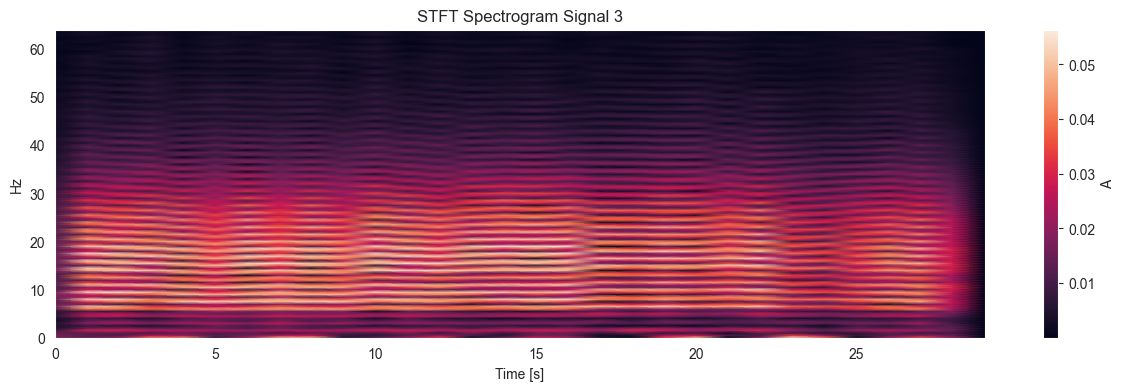

In [34]:
f, t, Zxx = signal.stft(x_dc_removed3, fs3, nperseg=256)

# Graficar el espectrograma
plt.figure(figsize=(15, 4))
plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.title('STFT Spectrogram Signal 3')
plt.ylabel('Hz')
plt.xlabel('Time [s]')
plt.colorbar(label='A')
plt.show()